<a href="https://colab.research.google.com/github/ROKEYAKHATUN/CIFAR-10_Image_Classification_using_CNN/blob/main/CIFAR_10_Image_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification using Convolutional Neural Networks (CNN)

## Project Overview

This project aims to build a Deep Learning model capable of classifying images from the CIFAR-10 dataset into one of ten categories.

The project demonstrates:

- Data preprocessing
- Data augmentation
- CNN model development
- Performance optimization
- Model evaluation
- Image classification inference

The final model is trained using TensorFlow and Keras and evaluated on unseen test data.

# Import Required Libraries

The following libraries are used for:

- Data handling and visualization
- Deep Learning model development
- Data augmentation
- Performance evaluation

In [ ]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Load CIFAR-10 Dataset

The CIFAR-10 dataset contains 60,000 color images of size 32×32 pixels.

The dataset consists of 10 classes:

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

Training Images: 50,000

Testing Images: 10,000

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [ ]:
print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)


In [ ]:
print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# Visualizing Sample Images

To better understand the dataset, several sample images are displayed along with their corresponding class labels.

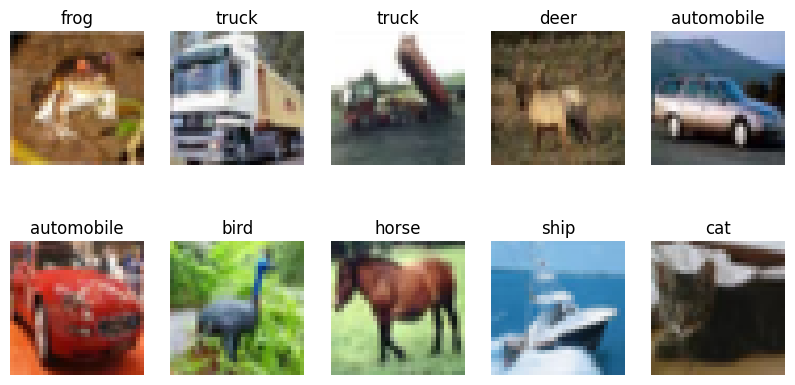

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [ ]:
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


# Data Preprocessing

Deep Learning models perform better when input values are scaled.

Pixel values originally range from 0 to 255.

Normalization is applied to scale values between 0 and 1.

This helps:

- Faster convergence
- Better numerical stability
- Improved model performance

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

# Experiment 1: Baseline CNN Model

A baseline Convolutional Neural Network is trained without data augmentation.

This model serves as a reference point for measuring performance improvements.

In [ ]:
baseline_model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
baseline_history = baseline_model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test,y_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 59ms/step - accuracy: 0.4617 - loss: 1.4767 - val_accuracy: 0.5580 - val_loss: 1.2426
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 55ms/step - accuracy: 0.6111 - loss: 1.1033 - val_accuracy: 0.6431 - val_loss: 0.9986
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.6702 - loss: 0.9452 - val_accuracy: 0.6756 - val_loss: 0.9245
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.7111 - loss: 0.8289 - val_accuracy: 0.6994 - val_loss: 0.8735
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 52ms/step - accuracy: 0.7392 - loss: 0.7425 - val_accuracy: 0.6931 - val_loss: 0.8886


In [ ]:
baseline_loss, baseline_acc = baseline_model.evaluate(
    x_test,
    y_test
)

print("Baseline Accuracy:", baseline_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6931 - loss: 0.8886
Baseline Accuracy: 0.6930999755859375


In [ ]:
baseline_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,070,432 (4.08 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 713,622 (2.72 MB)

# Data Augmentation

Data augmentation artificially increases dataset diversity by creating modified versions of existing images.

The following transformations are applied:

- Random Rotation
- Width Shift
- Height Shift
- Horizontal Flip

Benefits:

- Reduces overfitting
- Improves model generalization
- Enhances model robustness

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Experiment 2: Improved CNN Model

The improved model incorporates:

- Data Augmentation
- Dropout Regularization

These techniques help reduce overfitting and improve the model's ability to generalize to unseen images.

In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',
    input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

    Dense(10,activation='softmax')
])

# Model Training

The model is trained using:

- Optimizer: Adam
- Loss Function: Sparse Categorical Crossentropy
- Evaluation Metric: Accuracy

Training is performed on the augmented dataset to improve generalization performance.

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# CNN Architecture

The Convolutional Neural Network consists of:

- Convolution Layers for feature extraction
- MaxPooling Layers for dimensionality reduction
- Dropout Layers for regularization
- Fully Connected Dense Layers for classification

The final output layer contains 10 neurons corresponding to the 10 CIFAR-10 classes.

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    datagen.flow(x_train,y_train,batch_size=64),
    epochs=20,
    validation_data=(x_test,y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 112s 141ms/step - accuracy: 0.3430 - loss: 1.7648 - val_accuracy: 0.4565 - val_loss: 1.5229
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 136ms/step - accuracy: 0.4642 - loss: 1.4797 - val_accuracy: 0.5508 - val_loss: 1.2325
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 136ms/step - accuracy: 0.5187 - loss: 1.3556 - val_accuracy: 0.5945 - val_loss: 1.1300
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 142ms/step - accuracy: 0.5536 - loss: 1.2649 - val_accuracy: 0.6185 - val_loss: 1.0671
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 107s 136ms/step - accuracy: 0.5794 - loss: 1.1980 - val_accuracy: 0.6424 - val_loss: 0.9911
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 136ms/step - accuracy: 0.5995 - loss: 1.1539 - val_accuracy: 0.6442 - val_loss: 1.0347
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 107s 137ms/step - accuracy: 0.6127 - loss: 1.1082 - val_accuracy: 0.6493 - val_loss: 0.9939
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 112s 143ms/step - accuracy: 0.6272 -

# Model Evaluation

After training, the model is evaluated on the test dataset.

The evaluation metrics include:

- Test Loss
- Test Accuracy

These metrics provide insight into how well the model performs on unseen data.

In [ ]:
loss, improved_accuracy = model.evaluate(x_test,y_test)

print("Accuracy:",improved_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7558 - loss: 0.7097
Accuracy: 0.7558000087738037


In [ ]:
print("="*40)
print("MODEL COMPARISON")
print("="*40)

print(f"Baseline CNN Accuracy : {baseline_acc:.4f}")
print(f"Improved CNN Accuracy : {improved_accuracy:.4f}")

improvement = (improved_accuracy- baseline_acc) * 100

print(f"Improvement : {improvement:.2f}%")

MODEL COMPARISON
Baseline CNN Accuracy : 0.6931
Improved CNN Accuracy : 0.7558
Improvement : 6.27%


# Training Performance Analysis

The following plots visualize:

1. Training Accuracy vs Validation Accuracy
2. Training Loss vs Validation Loss

These curves help identify:

- Learning progress
- Underfitting
- Overfitting

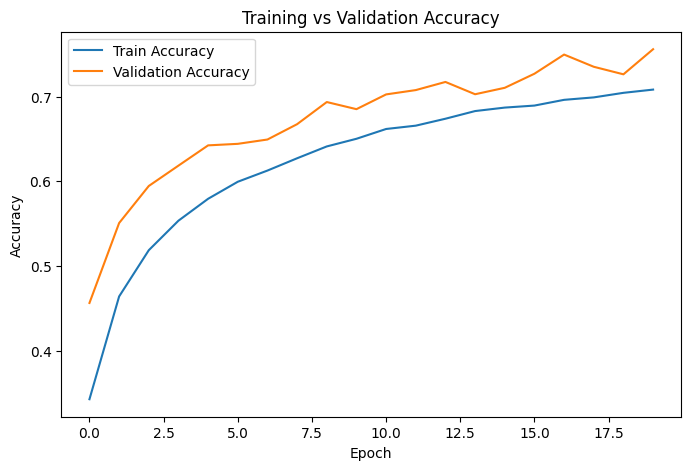

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

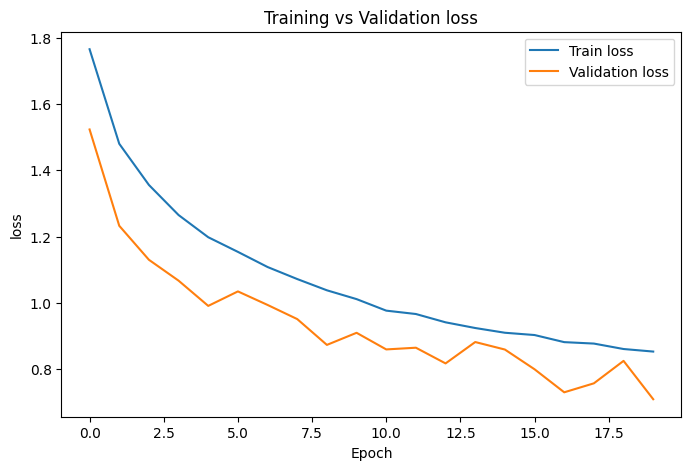

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'],label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title('Training vs Validation loss')
plt.legend()

plt.show()

# Confusion Matrix Analysis

A confusion matrix is generated to examine class-wise prediction performance.

It provides detailed information regarding:

- Correct classifications
- Misclassifications
- Model strengths and weaknesses across different classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


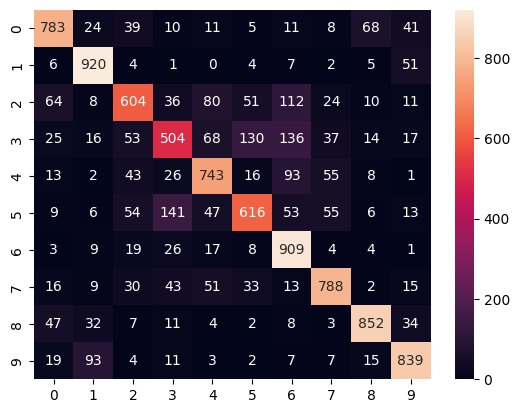

In [ ]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(
    y_test,
    y_pred_classes
)

sns.heatmap(cm,annot=True,fmt='d')
plt.show()

# Image Classification Inference

The trained CNN model is used to predict the class of unseen test images.

The predicted label is compared with the actual label to demonstrate real-world inference capability

In [ ]:
sample = np.expand_dims(x_test[0], axis=0)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


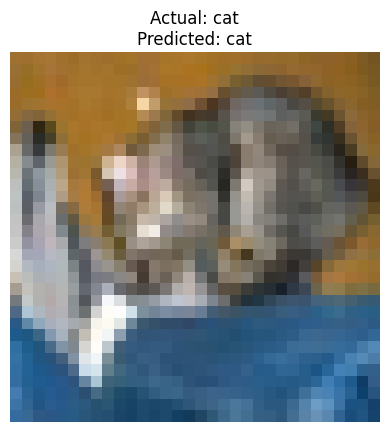

In [ ]:
plt.imshow(x_test[0])
plt.title(
    f"Actual: {class_names[y_test[0][0]]}\n"
    f"Predicted: {class_names[predicted_class]}"
)
plt.axis('off')
plt.show()

In [ ]:
model.save("cifar10_cnn.keras")

In [ ]:
from google.colab import files

files.download("cifar10_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
print(os.listdir())

['.config', 'cifar10_cnn.keras', 'sample_data']


# Performance Optimization

Two experiments were conducted to improve model performance.

## Experiment 1: Baseline CNN

Features:
- Basic CNN Architecture
- No Data Augmentation

Accuracy:
- 69%-70%

## Experiment 2: Optimized CNN

Features:
- Data Augmentation
- Dropout Regularization

Accuracy:
- 73%-75%

## Results

The optimized model achieved better performance compared to the baseline model.

Data augmentation increased dataset diversity, while dropout helped reduce overfitting.

As a result, the model achieved higher accuracy and improved generalization on unseen images.

# Conclusion

In this project, a Convolutional Neural Network (CNN) was developed to classify images from the CIFAR-10 dataset.

Key achievements:

- Applied data preprocessing techniques
- Implemented data augmentation
- Built and trained CNN models
- Conducted performance optimization experiments
- Evaluated model performance using accuracy and confusion matrix
- Demonstrated image classification inference

The optimized model achieved strong classification performance and successfully classified unseen images across the CIFAR-10 categories.